# Calculating the design matrix
- Map response as a regressor
- Then split it up based on valence and volatility
- See how they are correlated amongst each other

In [57]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import random
import os
from scipy.stats import skewnorm
from nilearn.glm.first_level import compute_regressor
from nilearn.glm.first_level import spm_hrf
from nilearn.glm.first_level import make_first_level_design_matrix, check_design_matrix
from nilearn.plotting import plot_design_matrix

plt.rcParams.update(plt.rcParamsDefault)
#pd.set_option('display.max_rows', None)

In [58]:
# Make output folder
output_dir = os.path.join('..','plots','fMRI','planning')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [59]:
input_dir = os.path.join('..', 'pre-processed', 'data_for_fMRI_modelling')
data = pd.read_csv(os.path.join(input_dir, 'combined_dataframe_binary_pilot_6.csv'), sep= ';')
data = data.sort_values(by=['trial'], ascending=[True])
data = data.reset_index(drop=True)
print(data)

     index  trial  emotional_cue_time response  objectively_correct  subjectively_correct  response_time   RT_s  feedback_time  stimuli_type  ...  stimuli_name  reward_amount  subject_id session  \
0      329      8          1726650769       up                 True                  True     1726650769  0.568     1726650771             1  ...      Happy_b2           -0.1         817       1   
1      330      9          1726650776     down                 True                  True     1726650776  0.654     1726650778             1  ...      Happy_b1            0.0         817       1   
2      331     10          1726650783       up                 True                 False     1726650783  0.706     1726650785             1  ...     Happy_b22           -0.1         817       1   
3        0     11          1726650790     down                 True                  True     1726650790  0.542     1726650792             2  ...     Angry_b25            0.0         817       1   
4      332

# Vary the ITI

In [60]:
# Now set ITI etc
trial_number =len(data)
median_iti = 3.5
simulate_iti = True
trial_list = list(range(trial_number))
tail = 0
standard_deviation = 0.33

# Add long breaks
long_breaks = trial_list[0::round(trial_number/3)]
print(long_breaks)

# Add short breaks
short_breaks = trial_list[0::30]
print(short_breaks)
print(f'hello {(skewnorm.rvs(tail, loc=median_iti, scale=standard_deviation, size=1))[0]}')

generated_onset=[0]
for i in range(1, trial_number):
    if i in long_breaks:
        print(i)
        #generated_onset.append(generated_onset[i-1] + skewnorm.rvs(tail, loc=median_iti, scale=standard_deviation, size=1)[0] + 60)
        #generated_onset.append(generated_onset[i-1] + skewnorm.rvs(tail, loc=median_iti, scale=standard_deviation, size=1)[0])
        generated_onset.append(generated_onset[i-1] + random.triangular(median_iti - 1, median_iti + 1) + 60)
    elif i in short_breaks and not i in long_breaks:
        print(i)
        #generated_onset.append(generated_onset[i-1] + skewnorm.rvs(tail, loc=median_iti, scale=standard_deviation, size=1)[0] + 8)
        generated_onset.append(generated_onset[i-1] + random.triangular(median_iti - 1, median_iti + 1) + 10)
    else:
        #generated_onset.append(generated_onset[i-1] + skewnorm.rvs(tail, loc=median_iti, scale=standard_deviation, size=1)[0])
        generated_onset.append(generated_onset[i-1] + random.triangular(median_iti - 1, median_iti + 1))

print(generated_onset)

if simulate_iti is True:
    data['emotional_cue_time'] = data['emotional_cue_time'] - data['emotional_cue_time'][0]
    data['emotional_cue_time_original'] = data['emotional_cue_time']
    data['emotional_cue_time'] = generated_onset
    
    data['response_time'] = data['emotional_cue_time'] + data['RT_s']
    
    print(data[['emotional_cue_time','emotional_cue_time_original','response_time','valence']])
else:
    data['emotional_cue_time'] = data['emotional_cue_time'] - data['emotional_cue_time'][0]
    print(data[['emotional_cue_time','valence']])
    print(f'average iti ')

[0, 207, 414]
[0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 360, 390, 420, 450, 480, 510, 540, 570, 600]
hello 3.4742792339075854
30
60
90
120
150
180
207
210
240
270
300
330
360
390
414
420
450
480
510
540
570
600
[0, 3.1665676166808465, 6.7569696229782314, 11.000358555755707, 14.434014082893416, 18.189750542092334, 21.723438183627156, 25.01824080537765, 28.502904014126123, 31.324586242525733, 35.2119297023783, 38.60670746358763, 42.35354122883395, 45.66969496899746, 49.1765950021143, 52.074369319209566, 55.16007826553181, 58.55079013293115, 61.29686742858325, 64.59542329699548, 68.38237361340167, 72.20855207770951, 75.75372831581345, 79.70230313014302, 82.92139823465811, 85.99302013989266, 89.52728248401158, 93.02696705194496, 97.04026256264841, 101.08021500694521, 115.11108499090575, 118.41873455302674, 121.61808261544974, 124.60317560554459, 128.15114598329592, 132.12874908232624, 135.12934511594804, 138.48136469695228, 142.0047511279964, 145.14347285019926, 148.596661739

### Figure of the ITI distribution

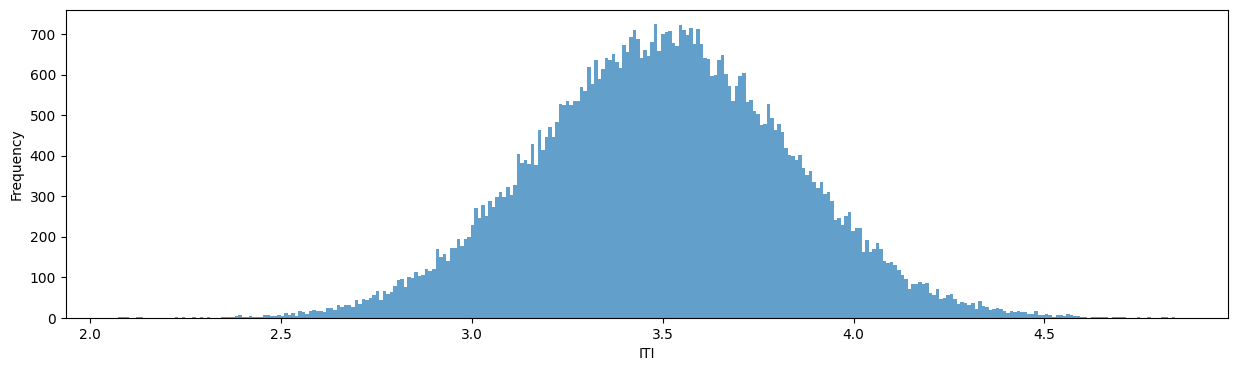

In [61]:
normal_curve_data = skewnorm.rvs(tail, loc=median_iti, scale=standard_deviation, size=trial_number*100)

plt.hist(normal_curve_data, bins=300, alpha=0.7)
plt.xlabel('ITI')
plt.ylabel('Frequency')
plt.savefig(os.path.join(output_dir, f'ITI_distribution.pdf'))
plt.show()

# Total duration

In [62]:
end_time = data['emotional_cue_time'].values[-1] + median_iti
end_time_min = end_time / 60
print(f'The full experiment takes {end_time_min:.0f} minutes')

The full experiment takes 42 minutes


# Quickly recode into something the design matrix can use

In [63]:
data['valence'] = data['valence'].replace({0:'angry', 1:'happy'})
data['congruency'] = data['congruency'].replace({0:'incongruent', 1:'congruent'})
data['volatility'] = data['volatility'].replace({0:'stable', 1:'volatile'})
data['valence-volatility'] = data['valence'] + '-' + data['volatility']

data['onset'] = data['emotional_cue_time']
data['duration'] = 1.8
print(data[['valence','congruency','volatility','valence-volatility','duration']])

    valence   congruency volatility valence-volatility  duration
0     happy  incongruent     stable       happy-stable       1.8
1     happy    congruent     stable       happy-stable       1.8
2     happy    congruent     stable       happy-stable       1.8
3     angry  incongruent     stable       angry-stable       1.8
4     happy    congruent     stable       happy-stable       1.8
..      ...          ...        ...                ...       ...
616   angry  incongruent   volatile     angry-volatile       1.8
617   angry  incongruent   volatile     angry-volatile       1.8
618   happy    congruent   volatile     happy-volatile       1.8
619   happy    congruent   volatile     happy-volatile       1.8
620   angry  incongruent   volatile     angry-volatile       1.8

[621 rows x 5 columns]


# Restructure the data into a timeseries

In [64]:
# Create the new dataframe by transforming the data
restructured_rows = []
for _, row in data.iterrows():
    restructured_rows.append({'trial_type': row['valence'], 'onset': row['onset'], 'duration': row['duration']})
    restructured_rows.append({'trial_type': row['congruency'], 'onset': row['onset'], 'duration': row['duration']})
    restructured_rows.append({'trial_type': row['volatility'], 'onset': row['onset'], 'duration': row['duration']})
    restructured_rows.append({'trial_type': row['valence-volatility'], 'onset': row['onset'], 'duration': row['duration']})

# Convert to dataframe
data_design_matrix = pd.DataFrame(restructured_rows)

print(data_design_matrix)

          trial_type        onset  duration
0              happy     0.000000       1.8
1        incongruent     0.000000       1.8
2             stable     0.000000       1.8
3       happy-stable     0.000000       1.8
4              happy     3.166568       1.8
...              ...          ...       ...
2479  happy-volatile  2487.917192       1.8
2480           angry  2491.762515       1.8
2481     incongruent  2491.762515       1.8
2482        volatile  2491.762515       1.8
2483  angry-volatile  2491.762515       1.8

[2484 rows x 3 columns]


# Scanner info

In [65]:
# Repetition time
tr = 1

# Define scan volumes
time_length = math.ceil(max(data_design_matrix['onset']))
n_volumes = np.linspace(0, time_length, (tr * time_length + 1))
total_volumes = len(n_volumes)

# Design matrix

In [66]:
plot_name = 'Design matrix'
events = pd.DataFrame(
    {"trial_type": data_design_matrix['trial_type'], "onset": data_design_matrix['onset'], "duration": data_design_matrix['duration']}
)
print(events)

          trial_type        onset  duration
0              happy     0.000000       1.8
1        incongruent     0.000000       1.8
2             stable     0.000000       1.8
3       happy-stable     0.000000       1.8
4              happy     3.166568       1.8
...              ...          ...       ...
2479  happy-volatile  2487.917192       1.8
2480           angry  2491.762515       1.8
2481     incongruent  2491.762515       1.8
2482        volatile  2491.762515       1.8
2483  angry-volatile  2491.762515       1.8

[2484 rows x 3 columns]


In [67]:
design_matrix = make_first_level_design_matrix(
    n_volumes,
    data_design_matrix,
    drift_model = None
)
design_matrix = design_matrix[['angry-stable','happy-stable','angry-volatile','happy-volatile','congruent','incongruent','constant']]
print(design_matrix)

        angry-stable  happy-stable  angry-volatile  happy-volatile     congruent   incongruent  constant
0.0     2.151563e-14 -1.397224e-14    3.268836e-14   -4.427408e-15  1.074161e-14  1.123077e-14       1.0
1.0     2.357558e-14  4.352714e-04    1.500645e-14   -2.031391e-16 -5.595638e-15  4.352714e-04       1.0
2.0     4.439516e-16  1.788379e-02   -3.945653e-17   -8.092729e-16 -1.387830e-15  1.788379e-02       1.0
3.0     9.296384e-16  1.067087e-01   -3.165219e-15   -1.638080e-14  5.049797e-15  1.067087e-01       1.0
4.0     5.577710e-15  2.752127e-01    1.264634e-14   -1.220962e-14  1.355179e-04  2.750772e-01       1.0
...              ...           ...             ...             ...           ...           ...       ...
2488.0  2.810137e-16  6.591637e-16    5.874008e-01    2.344999e-02  2.341067e-02  5.874401e-01       1.0
2489.0 -7.440466e-16 -5.202987e-16    4.132172e-01    2.033231e-01  2.033033e-01  4.132370e-01       1.0
2490.0 -2.683833e-16 -7.609543e-16    2.201561e-01    4

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/venv/lib/python3.10/site-packages/nilearn/glm/_utils.py:180: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")


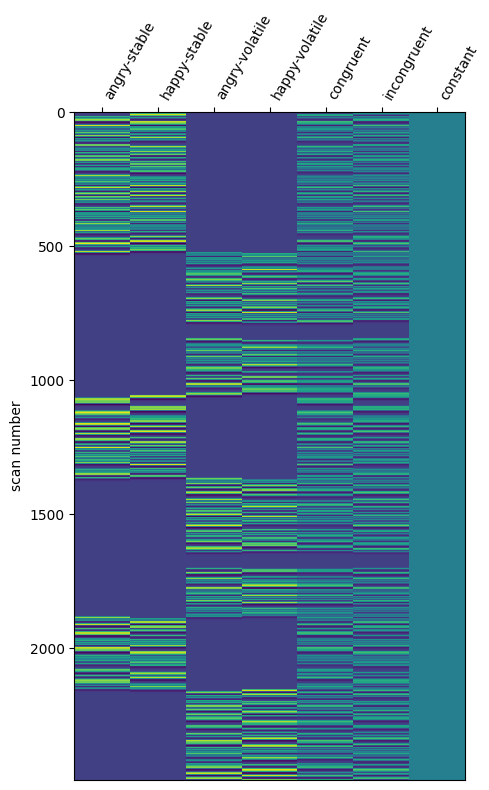

In [68]:
fig, ax = plt.subplots(figsize=(5, 8), nrows=1, ncols=1)
plot_design_matrix(design_matrix, ax=ax)
plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()

## Correlation matrix of the regressors

In [69]:
pd.set_option('display.width', 200)
correlation_matrix = design_matrix.corr()
correlation_matrix.round(3).to_csv(os.path.join(output_dir, 'regression_correlation_matrix.csv'), sep=';')
print(correlation_matrix)

                angry-stable  happy-stable  angry-volatile  happy-volatile  congruent  incongruent  constant
angry-stable        1.000000     -0.150270       -0.294174       -0.295754   0.219542    -0.034419  0.025922
happy-stable       -0.150270      1.000000       -0.304704       -0.287343  -0.011915     0.206422 -0.376604
angry-volatile     -0.294174     -0.304704        1.000000       -0.197370  -0.024114     0.247017  0.022868
happy-volatile     -0.295754     -0.287343       -0.197370        1.000000   0.219111    -0.027460 -0.096204
congruent           0.219542     -0.011915       -0.024114        0.219111   1.000000    -0.663182 -0.198884
incongruent        -0.034419      0.206422        0.247017       -0.027460  -0.663182     1.000000 -0.154399
constant            0.025922     -0.376604        0.022868       -0.096204  -0.198884    -0.154399  1.000000


# Raw HRF

In [70]:
plot_name = f'HRF for valence, first 200s, median ITI {median_iti}'
first_volume = 660
length = 860

fig = plt.figure(figsize=(15, 4))

n_volumes_selection = n_volumes[first_volume:length+1]
design_matrix_hrf_plot = design_matrix[first_volume:length]
#design_matrix_hrf_plot = design_matrix_hrf_plot.drop(columns=['congruent', 'incongruent', 'angry-stable', 'happy-stable', 'constant'])

plt.plot(design_matrix_hrf_plot['volatile'], label='angry-volatile', color='r')
plt.plot(design_matrix_hrf_plot['stable'], label='happy-volatile', color='g')
plt.xlabel("time (s)")
plt.legend()
plt.title(plot_name)

# adjust plot
plt.subplots_adjust(bottom=0.12)
plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_7524/1615567232.py:8: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  design_matrix_hrf_plot = design_matrix[first_volume:length]


KeyError: 'volatile'